In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import seaborn as sns

In [2]:
nsim = 10

In [3]:
colnames=['r', 'P(r)', 'err'] 

In [4]:
p_asn_data = pd.read_table("/data/mcohen3/CTD/Showalter_data/ps5n7/pS5N7_rep1_Pr.out", sep = r'\s+', names = colnames)
asn_data = pd.read_table("/data/mcohen3/CTD/Showalter_data/s5n7/S5N7_rep1_Pr.out", sep = r'\s+', names = colnames)

In [5]:
ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/reweighting/weights_100_frame_skip.dat', header=None)
p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/reweighting/weights_100_frame_skip.dat', header=None)

In [6]:
ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [7]:
p_ctd_weights_combined_raw

,0
0,9.103883e+19
1,1.822134e+19
2,3.327332e+19
3,2.006065e+19
4,1.114158e+20
...,...
489995,3.914873e+19
489996,3.433558e+19
489997,5.623902e+19
489998,6.578407e+19


In [8]:
dat_files = glob.glob("/data/mcohen3/CTD/asparagine/s5n7/distances/*.dat")

distance_df = pd.DataFrame()
list_of_pairs = []

for file in dat_files:
    df = pd.read_table(file, sep = '\s+')
    end_of_file = file.split('/')[-1]
    just_nums = end_of_file.split('.')[0]
    first_num = just_nums.split('-')[0]
    second_num = just_nums.split('-')[1]
    if ([second_num, first_num] in list_of_pairs) == True: # make sure no double counting
        continue
    list_of_pairs.append([first_num, second_num])
    distance_df = pd.concat([distance_df, df])
    
distance_df = distance_df.drop(['#Frame'], axis=1)
distance_df.columns = ['distance']

In [9]:
distance_df.head()
print(len(distance_df))
print(max(distance_df['distance']))
distance_df.head()

93100000
60.3524


,distance
0,6.7502
1,7.2022
2,6.6042
3,6.8281
4,6.9727


In [10]:
repeat_ctd_weights = pd.DataFrame(ctd_weights_combined)
repeat_ctd_weights = pd.concat([repeat_ctd_weights] * int(len(dat_files)/2), ignore_index=True)

In [11]:
repeat_ctd_weights.sum()

0    190.0
dtype: float64

In [12]:
len(dat_files)

380

In [13]:
distance_df

,distance
0,6.7502
1,7.2022
2,6.6042
3,6.8281
4,6.9727
...,...
489995,6.7502
489996,6.0136
489997,7.5053
489998,6.8441


In [14]:
p_dat_files = glob.glob("/data/mcohen3/CTD/asparagine/ps5n7/distances/*.dat")

p_distance_df = pd.DataFrame()
list_of_pairs = []

for file in p_dat_files:
    df = pd.read_table(file, sep = '\s+')
    end_of_file = file.split('/')[-1]
    just_nums = end_of_file.split('.')[0]
    first_num = just_nums.split('-')[0]
    second_num = just_nums.split('-')[1]
    if ([second_num, first_num] in list_of_pairs) == True: # make sure no double counting
        continue
    list_of_pairs.append([first_num, second_num])
    p_distance_df = pd.concat([p_distance_df, df])
    
p_distance_df = p_distance_df.drop(['#Frame'], axis=1)
p_distance_df.columns = ['distance']

In [15]:
repeat_p_ctd_weights = pd.DataFrame(p_ctd_weights_combined)
repeat_p_ctd_weights = pd.concat([repeat_p_ctd_weights] * int(len(dat_files)/2), ignore_index=True)


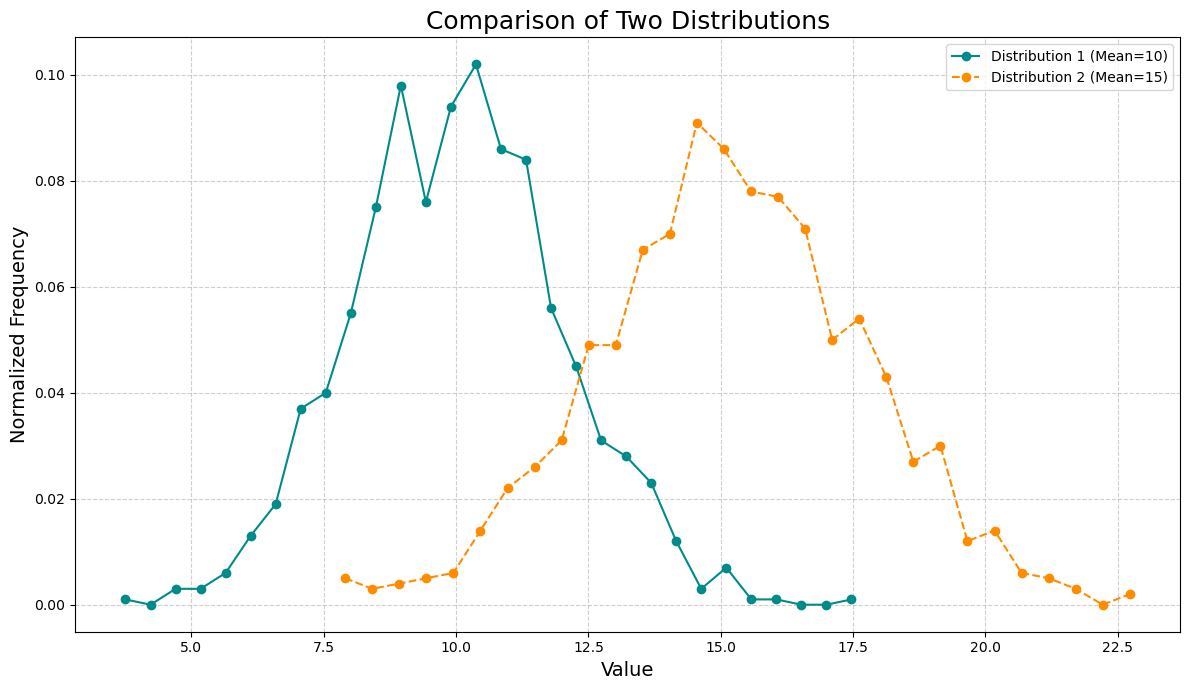

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import random

def normalized_histogram_plot(data, bins, weights=None, ax=None, **plot_kwargs):
    """
    Calculates and plots a normalized frequency line on a given Matplotlib axes.

    If no axes are provided, it creates a new figure and axes.

    Args:
        data (list or np.ndarray): A list or NumPy array of numerical data.
        bins (int): The number of bins to use for the histogram.
        weights (list or np.ndarray, optional): An array of weights for each data point.
        ax (matplotlib.axes.Axes, optional): The axes object to draw the plot on.
                                             If None, a new figure and axes are created.
        **plot_kwargs: Keyword arguments to be passed directly to ax.plot().
                       Examples: color='red', label='My Data', linestyle='-'.

    Returns:
        matplotlib.axes.Axes: The axes object that was used for plotting.
    """
    # --- Data Calculation ---
    if not isinstance(data, np.ndarray):
        data = np.array(data)
    
    if weights is not None:
        if not isinstance(weights, np.ndarray):
            weights = np.array(weights)
        if len(data) != len(weights):
            raise ValueError("The 'data' and 'weights' arrays must have the same length.")

    freqs, bin_edges = np.histogram(data, bins=bins, weights=weights)
    total_weight = np.sum(weights) if weights is not None else float(len(data))
    
    if total_weight == 0:
        normalized_freqs = np.zeros_like(freqs, dtype=float)
    else:
        normalized_freqs = freqs / total_weight

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    # --- Plotting Logic ---
    # If no axes are provided, create a new figure and axes.
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the data on the provided or newly created axes.
    # **plot_kwargs allows for flexible styling (color, label, etc.)
    ax.plot(bin_centers, normalized_freqs, marker='o', **plot_kwargs)
    
    # Return the axes so it can be further customized or reused.
    return ax

if __name__ == '__main__':
    # --- Example: Plotting Two Distributions on the Same Figure ---

    # 1. Generate two different datasets
    np.random.seed(42)
    data1 = np.random.normal(loc=10, scale=2, size=1000)
    data2 = np.random.normal(loc=15, scale=2.5, size=1000)

    # 2. Create a single figure and axes object to hold the plots.
    #    This is done ONCE, outside the function.
    fig, ax = plt.subplots(figsize=(12, 7))

    # 3. Call the function for the first dataset, passing the axes object 'ax'.
    #    We use plot_kwargs for styling.
    normalized_histogram_plot(data1, bins=30, ax=ax, 
                              label='Distribution 1 (Mean=10)', color='darkcyan', linestyle='-')

    # 4. Call the function for the second dataset, passing the SAME axes object 'ax'.
    normalized_histogram_plot(data2, bins=30, ax=ax, 
                              label='Distribution 2 (Mean=15)', color='darkorange', linestyle='--')

    # 5. Now, customize the final combined plot using the 'ax' object.
    ax.set_title('Comparison of Two Distributions', fontsize=18)
    ax.set_xlabel('Value', fontsize=14)
    ax.set_ylabel('Normalized Frequency', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add a legend to identify the plots.
    ax.legend()

    # 6. Display the final figure.
    plt.tight_layout()
    plt.show()


(0.0, 0.025)

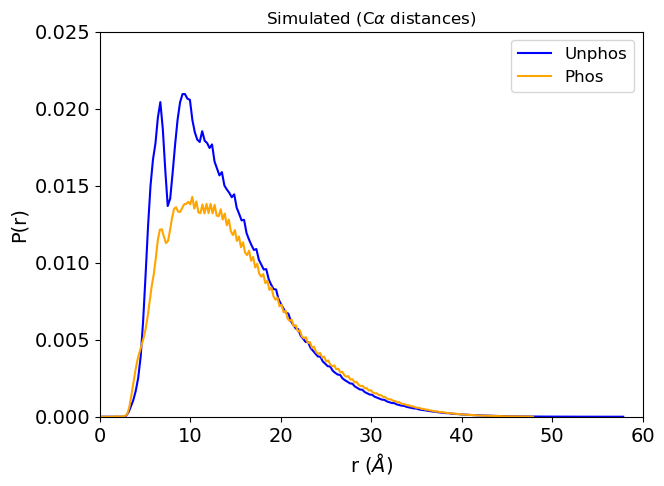

In [17]:
fig1, ax1 = plt.subplots(figsize=(7,5))

#bins=asn_data['r']

ax_unphos = normalized_histogram_plot(distance_df, bins=asn_data['r'], weights=repeat_ctd_weights, color='blue', label='Unphos', ax=ax1)
ax_phos = normalized_histogram_plot(p_distance_df, bins=p_asn_data['r'], weights=repeat_p_ctd_weights, color='orange', label='Phos', ax=ax1)

# Plot a line for the average distance between adjacent Ca's
#ax1.axvline(3.8, linestyle='--', color='black')

for line in ax1.lines:
    line.set_marker('None') # removes markers from all lines
    
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(r'Simulated (C$\alpha$ distances)')
ax1.set_xlabel(r'r ($\AA$)', fontsize = 14)
ax1.set_ylabel('P(r)', fontsize = 14)
ax1.legend(fontsize = 12)
ax1.set_xlim(0,60)
ax1.set_ylim(0,0.025)

In [18]:
freqs_p_asn.sum()

190.00000000000063

In [19]:
freqs_asn.sum()

189.9999172797161

In [20]:
distance_df.max()

distance    60.3524
dtype: float64

In [21]:
distance_df

,distance
0,6.7502
1,7.2022
2,6.6042
3,6.8281
4,6.9727
...,...
489995,6.7502
489996,6.0136
489997,7.5053
489998,6.8441


In [22]:
freqs_asn[0:70].sum()

154.1903999314774

In [23]:
asn_data['r'][150]

40.85

In [24]:
freqs_p_asn[0:70].sum()

144.33878019771595

In [25]:
freqs_asn[70:150].sum()

35.54023804349157

In [26]:
freqs_p_asn[70:150].sum()

45.381537930879745

ValueError: x and y must have same first dimension, but have shapes (214,) and (213,)

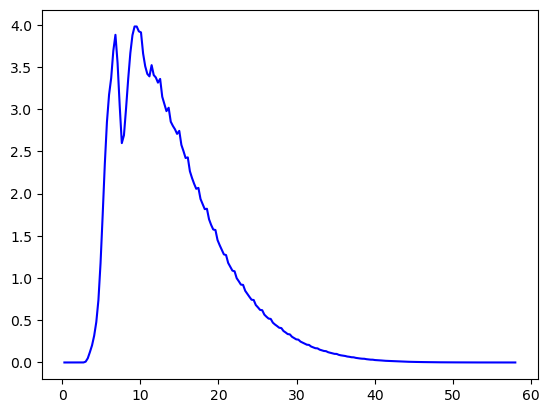

In [27]:
plt.figure()
plt.plot(asn_data['r'][1:], freqs_asn, color='blue')
plt.plot(p_asn_data['r'][1:], freqs_p_asn, color='orange')

In [ ]:
asn_data

In [18]:
unphos_xdata = ax_unphos.lines[0].get_xdata()
unphos_ydata = ax_unphos.lines[0].get_ydata()

phos_xdata = ax_phos.lines[1].get_xdata()
phos_ydata = ax_phos.lines[1].get_ydata()

Current dimensions: 7.0 x 5.0 inches
New dimensions: 3.25 x 2.3214285714285716 inches


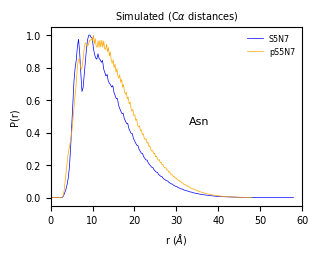

In [20]:
plt.figure(figsize=(7,5))
plt.plot(unphos_xdata, unphos_ydata/unphos_ydata.max(), linewidth=0.5, color='blue', label='S5N7')
plt.plot(phos_xdata, phos_ydata/phos_ydata.max(), linewidth=0.5, color='orange', label='pS5N7')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
plt.xlabel(r'r ($\AA$)', fontsize = 7)
plt.ylabel('P(r)', fontsize = 7)
plt.title(r'Simulated (C$\alpha$ distances)', fontsize=7)
plt.legend(fontsize = 5.75, frameon=False)
plt.xlim(0,60)
#plt.ylim(0,0.02)
plt.text(33, 0.5, 'Asn', fontsize=8, verticalalignment='top')

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('sim_Pr_asn.png', dpi=300, bbox_inches='tight')

plt.show()